# LLM Stable Attractor Demonstration (DLMH)

This notebook demonstrates:
- Stable vs unstable vs stable-wrong behaviour in an LLM
- Measurement of stability (invariance)
- Measurement of accuracy (ground truth agreement)
- Classification into regimes

⚠️ NOTE:
This notebook requires a locally installed Mistral model.
No model weights are included. Users must supply their own model path.

## Setup (User must configure model path)

Ensure you already have a downloaded model (e.g. Mistral-7B).
Set the path below to your local model directory.

⚠️ This notebook requires a locally installed model.
Set MODEL_PATH to your own Hugging Face snapshot directory.
No downloads are performed.

In [1]:
import os
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from collections import Counter

G:\python_install\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Optional but good practice
os.environ["HF_HOME"] = r"G:\train_jw\hf_cache"

MODEL_PATH = r"G:\train_jw\hf_cache\transformers\models--mistralai--Mistral-7B-Instruct-v0.3\snapshots\c170c708c41dac9275d15a8fff4eca08d52bab71"

print("Loading model from local snapshot...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float16,
    device_map="auto",
    local_files_only=True
)

print("✅ Model loaded locally (no downloads)")

Loading model from local snapshot...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Model loaded locally (no downloads)


## Helper: Generate Response

In [3]:
def generate(prompt, max_new_tokens=5):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

## Prompt Variants (Perturbations)

In [4]:
def generate_variants(base_prompt):
    return [
        base_prompt,
        base_prompt.replace("=", "equals"),
        "Consider the following: " + base_prompt,
        base_prompt + " What is the answer?",
        base_prompt.replace("Y", "the variable Y"),
    ]

## Run Trials

In [5]:
def run_trials(prompt, correct_answer, trials=3):
    results = []
    variants = generate_variants(prompt)
    
    for _ in range(trials):
        for v in variants:
            out = generate(v)
            results.append(out)

    # Stability: most common response frequency
    counts = Counter(results)
    most_common, freq = counts.most_common(1)[0]
    stability = freq / len(results)

    # Accuracy
    accuracy = sum(correct_answer in r for r in results) / len(results)

    return stability, accuracy, most_common

## Example: Y Attractor

In [6]:
prompt = "If Y = 5, what is Y?"
correct = "5"

s, a, mc = run_trials(prompt, correct)

print("Stability:", s)
print("Accuracy:", a)
print("Most common output:", mc)

Stability: 0.2
Accuracy: 1.0
Most common output: If Y = 5, what is Y?

Y = 


## Scatter Experiment

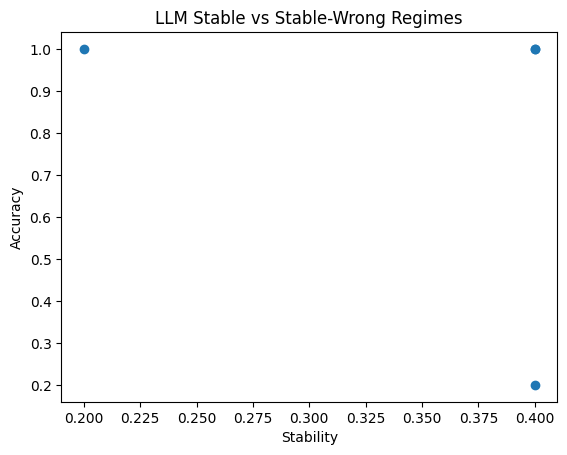

In [7]:
test_prompts = [
    ("If Y = 5, what is Y?", "5"),
    ("If X = 3, what is X?", "3"),
    ("2 + 2 = ?", "4"),
    ("If Z = 7, what is Z?", "7"),
]

points = []

for p, ans in test_prompts:
    s, a, _ = run_trials(p, ans)
    points.append((s, a))

points = np.array(points)

import matplotlib.pyplot as plt

plt.scatter(points[:,0], points[:,1])
plt.xlabel("Stability")
plt.ylabel("Accuracy")
plt.title("LLM Stable vs Stable-Wrong Regimes")
plt.show()

## Formal Classification (DLMH)

S = stability (response invariance)
A = accuracy (ground truth agreement)

- Stable correct: S high, A high
- Unstable: S low
- Stable wrong: S high, A low

This demonstrates that consistency does not imply correctness in LLM inference.